In [1]:
# --- Cell 1: Imports ---
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.metrics import confusion_matrix, accuracy_score
RANDOM_STATE = 55

from google.colab import drive
drive.mount('/content/drive')

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
DATA_PATH   = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Dataset/scaled_dataset/'
FIG_PATH    = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/Figures/'


Mounted at /content/drive


In [2]:
# --- Cell 2: Load arrays ---
X_train = np.load(DATA_PATH + 'X_train_scaled.npy')
X_val   = np.load(DATA_PATH + 'X_val_scaled.npy')
X_test  = np.load(DATA_PATH + 'X_test_scaled.npy')
y_train = np.load(DATA_PATH + 'y_train_bal.npy')
y_val   = np.load(DATA_PATH + 'y_val.npy')
y_test  = np.load(DATA_PATH + 'y_test.npy')

print("Shapes loaded:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Shapes loaded:
  X_train: (45728, 108), y_train: (45728,)
  X_val:   (27495, 108),   y_val:   (27495,)
  X_test:  (27495, 108),  y_test:  (27495,)


Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    4.7s finished
[Parallel(n_jobs=44)]: Using backend ThreadingBackend with 44 concurrent workers.
[Parallel(n_jobs=44)]: Done 112 tasks      | elapsed:    0.0s
[Parallel(n_jobs=44)]: Done 400 out of 400 | elapsed:    0.1s finished
[Parallel(n_jobs=44)]: Using backend ThreadingBackend with 44 concurrent workers.


Training complete.

  RF — TRAINING SET
  Metric                            Value
  ----------------------------------------
  Overall Accuracy                 99.93%
  Macro Precision                  99.94%
  Macro Recall                     99.94%
  Macro F1                         99.94%
  ----------------------------------------
  Islanding Precision              99.99%
  Islanding Recall                 99.82%
  Islanding F1                     99.91%
  False Alarms                          1
  Missed Islanding                     31

  Classification Report:
               precision    recall  f1-score   support

Non-islanding     0.9982    0.9999    0.9991     17136
    Islanding     0.9999    0.9982    0.9991     17136
   Line Fault     1.0000    1.0000    1.0000     11456

     accuracy                         0.9993     45728
    macro avg     0.9994    0.9994    0.9994     45728
 weighted avg     0.9993    0.9993    0.9993     45728



[Parallel(n_jobs=44)]: Done 112 tasks      | elapsed:    0.1s
[Parallel(n_jobs=44)]: Done 400 out of 400 | elapsed:    0.2s finished
[Parallel(n_jobs=44)]: Using backend ThreadingBackend with 44 concurrent workers.
[Parallel(n_jobs=44)]: Done 112 tasks      | elapsed:    0.0s
[Parallel(n_jobs=44)]: Done 400 out of 400 | elapsed:    0.1s finished



  RF — VALIDATION SET
  Metric                            Value
  ----------------------------------------
  Overall Accuracy                 98.34%
  Macro Precision                  98.43%
  Macro Recall                     98.03%
  Macro F1                         98.22%
  ----------------------------------------
  Islanding Precision              96.95%
  Islanding Recall                 95.06%
  Islanding F1                     96.00%
  False Alarms                        171
  Missed Islanding                    282

  Classification Report:
               precision    recall  f1-score   support

Non-islanding     0.9844    0.9903    0.9873     17959
    Islanding     0.9695    0.9506    0.9600      5712
   Line Fault     0.9990    1.0000    0.9995      3824

     accuracy                         0.9834     27495
    macro avg     0.9843    0.9803    0.9822     27495
 weighted avg     0.9833    0.9834    0.9833     27495


  RF — TEST SET
  Metric                            Valu

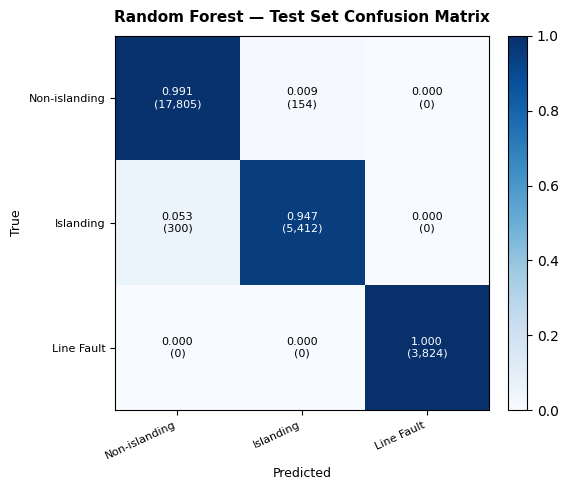

Model and predictions saved.


In [3]:
# ================================================================
#  RANDOM FOREST — Islanding Detection
# ================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import numpy as np
import matplotlib.pyplot as plt

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
save_path   = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/'

# ── Train ────────────────────────────────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators    = 400,
    max_depth       = 40,
    min_samples_split = 10,
    min_samples_leaf  = 2,
    max_features    = 'sqrt',
    class_weight    = None,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = 1
)
rf_model.fit(X_train, y_train)
print("Training complete.")

# ── Evaluate on all three splits ────────────────────────────────
def evaluate_model(name, model, X, y_true):
    preds    = model.predict(X)
    non_mask = y_true == 0
    isl_mask = y_true == 1
    isl_total = isl_mask.sum()

    acc      = accuracy_score(y_true, preds) * 100
    prec_mac = precision_score(y_true, preds, average='macro',
                               zero_division=0) * 100
    rec_mac  = recall_score(y_true, preds, average='macro',
                            zero_division=0) * 100
    f1_mac   = f1_score(y_true, preds, average='macro',
                        zero_division=0) * 100
    isl_prec = precision_score(y_true, preds, labels=[1],
                               average='micro', zero_division=0) * 100
    isl_rec  = recall_score(y_true, preds, labels=[1],
                            average='micro', zero_division=0) * 100
    isl_f1   = f1_score(y_true, preds, labels=[1],
                        average='micro', zero_division=0) * 100
    fa       = ((preds == 1) & non_mask).sum()
    missed   = ((preds != 1) & isl_mask).sum()

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  {'Metric':<28} {'Value':>10}")
    print(f"  {'-'*40}")
    print(f"  {'Overall Accuracy':<28} {acc:>9.2f}%")
    print(f"  {'Macro Precision':<28} {prec_mac:>9.2f}%")
    print(f"  {'Macro Recall':<28} {rec_mac:>9.2f}%")
    print(f"  {'Macro F1':<28} {f1_mac:>9.2f}%")
    print(f"  {'-'*40}")
    print(f"  {'Islanding Precision':<28} {isl_prec:>9.2f}%")
    print(f"  {'Islanding Recall':<28} {isl_rec:>9.2f}%")
    print(f"  {'Islanding F1':<28} {isl_f1:>9.2f}%")
    print(f"  {'False Alarms':<28} {fa:>10,}")
    print(f"  {'Missed Islanding':<28} {missed:>10,}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, preds,
                                target_names=CLASS_NAMES, digits=4))
    return preds

rf_train_preds = evaluate_model("RF — TRAINING SET",
                                 rf_model, X_train, y_train)
rf_val_preds   = evaluate_model("RF — VALIDATION SET",
                                 rf_model, X_val, y_val)
rf_test_preds  = evaluate_model("RF — TEST SET",
                                 rf_model, X_test, y_test)

# ── Confusion matrix ─────────────────────────────────────────────
def plot_cm(preds, y_true, title, save_name):
    cm      = confusion_matrix(y_true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
    ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm_norm[i,j]:.3f}\n({cm[i,j]:,})",
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_norm[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path + f'Figures/{save_name}.png', dpi=150,
                bbox_inches='tight')
    plt.show()

plot_cm(rf_test_preds, y_test,
        'Random Forest — Test Set Confusion Matrix',
        'rf_confusion_matrix')

# ── Save model and predictions ───────────────────────────────────
import joblib
joblib.dump(rf_model, save_path + 'rf_model.pkl')
np.save(save_path + 'rf_train_preds.npy', rf_train_preds)
np.save(save_path + 'rf_val_preds.npy',   rf_val_preds)
np.save(save_path + 'rf_test_preds.npy',  rf_test_preds)
print("Model and predictions saved.")

Sweeping min_samples_split...
  min_samples_split=   2  train=100.00%  val=98.31%
  min_samples_split=   5  train=100.00%  val=98.30%
  min_samples_split=  10  train=99.91%  val=98.34%
  min_samples_split=  20  train=99.33%  val=98.21%
  min_samples_split=  30  train=98.78%  val=98.15%
  min_samples_split=  50  train=98.17%  val=98.05%
  min_samples_split=  75  train=97.85%  val=97.84%
  min_samples_split= 100  train=97.63%  val=97.66%

Sweeping max_depth...
  max_depth=    5  train=93.09%  val=94.93%
  max_depth=   10  train=96.80%  val=97.53%
  max_depth=   15  train=98.40%  val=98.11%
  max_depth=   20  train=99.84%  val=98.25%
  max_depth=   25  train=100.00%  val=98.29%
  max_depth=   30  train=100.00%  val=98.29%
  max_depth=   40  train=100.00%  val=98.32%
  max_depth=   50  train=100.00%  val=98.30%
  max_depth= None  train=100.00%  val=98.30%

Sweeping n_estimators...
  n_estimators=  10  train=99.76%  val=97.72%
  n_estimators=  25  train=99.92%  val=98.06%
  n_estimators=  5

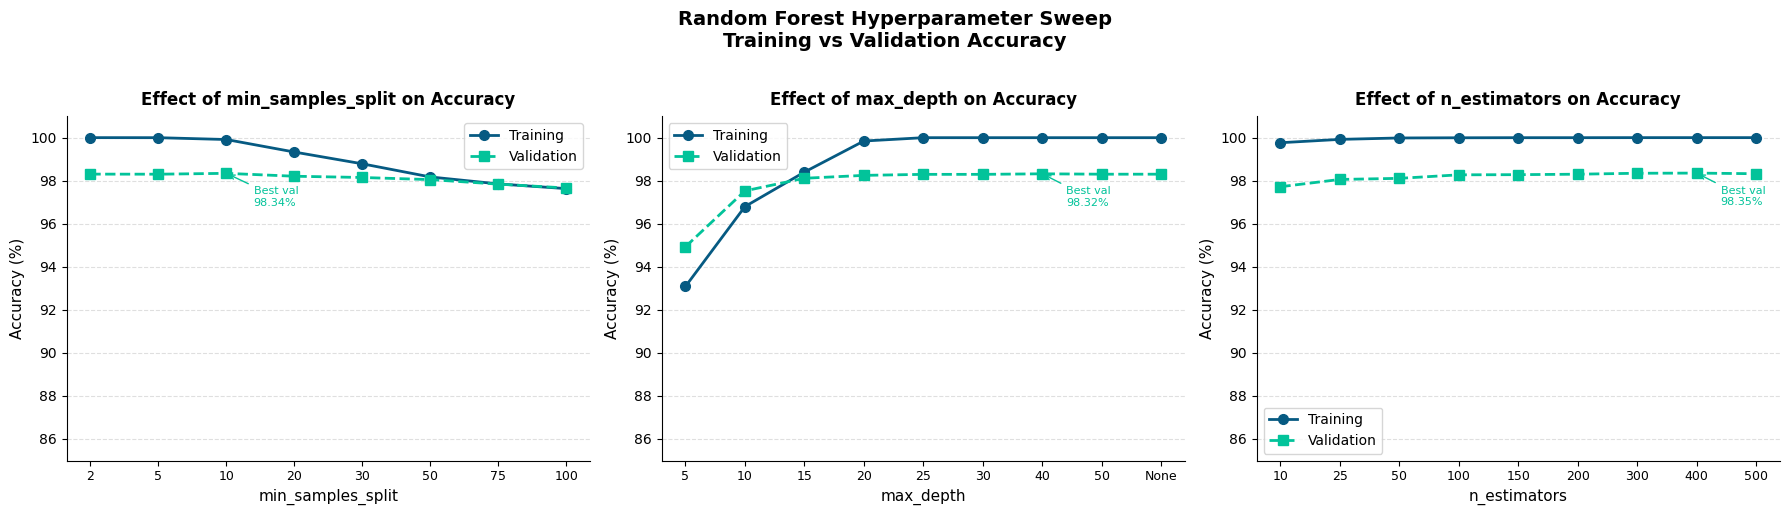


  Best hyperparameter values by validation accuracy
  min_samples_split: 10 (val acc = 98.34%)
  max_depth:         40 (val acc = 98.32%)
  n_estimators:      400 (val acc = 98.35%)
Hyperparameter sweep plot saved.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# ── Common plot styling ──────────────────────────────────────────
def style_ax(ax, xlabel, title):
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([85, 101])

# ── Base RF parameters (fixed while sweeping one at a time) ──────
BASE_PARAMS = dict(
    n_estimators      = 200,
    max_depth         = None,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',
    random_state      = 42,
    n_jobs            = -1,
)

# ================================================================
#  SWEEP 1 — min_samples_split
# ================================================================
min_split_values = [2, 5, 10, 20, 30, 50, 75, 100]

train_acc_split = []
val_acc_split   = []

print("Sweeping min_samples_split...")
for val in min_split_values:
    params = {**BASE_PARAMS, 'min_samples_split': val}
    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)
    train_acc_split.append(accuracy_score(y_train,
                           rf.predict(X_train)) * 100)
    val_acc_split.append(accuracy_score(y_val,
                         rf.predict(X_val)) * 100)
    print(f"  min_samples_split={val:>4}  "
          f"train={train_acc_split[-1]:.2f}%  "
          f"val={val_acc_split[-1]:.2f}%")

# ================================================================
#  SWEEP 2 — max_depth
# ================================================================
max_depth_values = [5, 10, 15, 20, 25, 30, 40, 50, None]
max_depth_labels = ['5', '10', '15', '20', '25', '30', '40', '50', 'None']

train_acc_depth = []
val_acc_depth   = []

print("\nSweeping max_depth...")
for d in max_depth_values:
    params = {**BASE_PARAMS, 'max_depth': d}
    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)
    train_acc_depth.append(accuracy_score(y_train,
                           rf.predict(X_train)) * 100)
    val_acc_depth.append(accuracy_score(y_val,
                         rf.predict(X_val)) * 100)
    print(f"  max_depth={str(d):>5}  "
          f"train={train_acc_depth[-1]:.2f}%  "
          f"val={val_acc_depth[-1]:.2f}%")

# ================================================================
#  SWEEP 3 — n_estimators
# ================================================================
n_estimators_values = [10, 25, 50, 100, 150, 200, 300, 400, 500]

train_acc_nest = []
val_acc_nest   = []

print("\nSweeping n_estimators...")
for n in n_estimators_values:
    params = {**BASE_PARAMS, 'n_estimators': n}
    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)
    train_acc_nest.append(accuracy_score(y_train,
                          rf.predict(X_train)) * 100)
    val_acc_nest.append(accuracy_score(y_val,
                        rf.predict(X_val)) * 100)
    print(f"  n_estimators={n:>4}  "
          f"train={train_acc_nest[-1]:.2f}%  "
          f"val={val_acc_nest[-1]:.2f}%")

# ================================================================
#  PLOT ALL THREE SWEEPS
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest Hyperparameter Sweep\nTraining vs Validation Accuracy',
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: min_samples_split ────────────────────────────────────
ax = axes[0]
ax.plot(range(len(min_split_values)), train_acc_split,
        'o-', color='#065A82', linewidth=2, markersize=7,
        label='Training')
ax.plot(range(len(min_split_values)), val_acc_split,
        's--', color='#02C39A', linewidth=2, markersize=7,
        label='Validation')
ax.set_xticks(range(len(min_split_values)))
ax.set_xticklabels([str(v) for v in min_split_values], fontsize=9)

# Annotate best val point
best_idx = int(np.argmax(val_acc_split))
ax.annotate(f'Best val\n{val_acc_split[best_idx]:.2f}%',
            xy=(best_idx, val_acc_split[best_idx]),
            xytext=(best_idx + 0.4, val_acc_split[best_idx] - 1.5),
            fontsize=8, color='#02C39A',
            arrowprops=dict(arrowstyle='->', color='#02C39A'))
style_ax(ax, 'min_samples_split',
         'Effect of min_samples_split on Accuracy')

# ── Plot 2: max_depth ────────────────────────────────────────────
ax = axes[1]
ax.plot(range(len(max_depth_values)), train_acc_depth,
        'o-', color='#065A82', linewidth=2, markersize=7,
        label='Training')
ax.plot(range(len(max_depth_values)), val_acc_depth,
        's--', color='#02C39A', linewidth=2, markersize=7,
        label='Validation')
ax.set_xticks(range(len(max_depth_values)))
ax.set_xticklabels(max_depth_labels, fontsize=9)

best_idx = int(np.argmax(val_acc_depth))
ax.annotate(f'Best val\n{val_acc_depth[best_idx]:.2f}%',
            xy=(best_idx, val_acc_depth[best_idx]),
            xytext=(best_idx + 0.4, val_acc_depth[best_idx] - 1.5),
            fontsize=8, color='#02C39A',
            arrowprops=dict(arrowstyle='->', color='#02C39A'))
style_ax(ax, 'max_depth',
         'Effect of max_depth on Accuracy')

# ── Plot 3: n_estimators ─────────────────────────────────────────
ax = axes[2]
ax.plot(range(len(n_estimators_values)), train_acc_nest,
        'o-', color='#065A82', linewidth=2, markersize=7,
        label='Training')
ax.plot(range(len(n_estimators_values)), val_acc_nest,
        's--', color='#02C39A', linewidth=2, markersize=7,
        label='Validation')
ax.set_xticks(range(len(n_estimators_values)))
ax.set_xticklabels([str(v) for v in n_estimators_values], fontsize=9)

best_idx = int(np.argmax(val_acc_nest))
ax.annotate(f'Best val\n{val_acc_nest[best_idx]:.2f}%',
            xy=(best_idx, val_acc_nest[best_idx]),
            xytext=(best_idx + 0.4, val_acc_nest[best_idx] - 1.5),
            fontsize=8, color='#02C39A',
            arrowprops=dict(arrowstyle='->', color='#02C39A'))
style_ax(ax, 'n_estimators',
         'Effect of n_estimators on Accuracy')

plt.tight_layout()
plt.savefig(save_path + 'Figures/rf_hyperparameter_sweep.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print best values ────────────────────────────────────────────
print("\n" + "="*55)
print("  Best hyperparameter values by validation accuracy")
print("="*55)
print(f"  min_samples_split: "
      f"{min_split_values[int(np.argmax(val_acc_split))]} "
      f"(val acc = {max(val_acc_split):.2f}%)")
print(f"  max_depth:         "
      f"{max_depth_labels[int(np.argmax(val_acc_depth))]} "
      f"(val acc = {max(val_acc_depth):.2f}%)")
print(f"  n_estimators:      "
      f"{n_estimators_values[int(np.argmax(val_acc_nest))]} "
      f"(val acc = {max(val_acc_nest):.2f}%)")
print("="*55)
print("Hyperparameter sweep plot saved.")

In [6]:
# ── RF threshold predictions ─────────────────────────────────────
rf_test_probs    = rf_model.predict_proba(X_test)
rf_thresh_preds  = np.where(rf_test_probs[:, 1] >= 0.45, 1,
                             np.where(rf_test_probs[:, 0] >=
                                      rf_test_probs[:, 2], 0, 2))

[Parallel(n_jobs=44)]: Using backend ThreadingBackend with 44 concurrent workers.
[Parallel(n_jobs=44)]: Done 112 tasks      | elapsed:    0.0s
[Parallel(n_jobs=44)]: Done 400 out of 400 | elapsed:    0.1s finished


In [7]:
np.save(save_path + 'rf_thresh_test_preds.npy',  rf_thresh_preds)


# ── Verify ───────────────────────────────────────────────────────
print("Saved successfully. Verifying...")
for fname in ['xgb_test_preds.npy', 'xgb_thresh_test_preds.npy',
              'rf_thresh_test_preds.npy', 'xgb_model.pkl']:
    import os
    exists = os.path.exists(save_path + fname)
    print(f"  {fname}: {'✓' if exists else '✗ NOT FOUND'}")

Saved successfully. Verifying...
  xgb_test_preds.npy: ✓
  xgb_thresh_test_preds.npy: ✓
  rf_thresh_test_preds.npy: ✓
  xgb_model.pkl: ✗ NOT FOUND
